# 03 — Regression
**Referencias:** ESL Cap. 3 (Linear Methods for Regression) · Géron Cap. 4

## Regresión Lineal — formulación (ESL 3.1)

$$\hat{\beta} = \underset{\beta}{\arg\min} \sum_{i=1}^{N} (y_i - \beta_0 - \sum_j x_{ij}\beta_j)^2 = (X^TX)^{-1}X^Ty$$

El problema: si las columnas de $X$ son casi linealmente dependientes, $(X^TX)$ se vuelve casi singular → coeficientes **inestables**, varianza muy alta.

## Ridge Regression — L2 (ESL 3.4.1)
Agrega penalización sobre el tamaño de los coeficientes:
$$\hat{\beta}^{\text{ridge}} = \underset{\beta}{\arg\min}\left\{ \sum_{i=1}^N (y_i - \beta_0 - \sum_j x_{ij}\beta_j)^2 + \lambda \sum_j \beta_j^2 \right\}$$
Solución analítica: $\hat{\beta}^{\text{ridge}} = (X^TX + \lambda I)^{-1}X^Ty$

## Lasso — L1 (ESL 3.4.2)
$$\hat{\beta}^{\text{lasso}} = \underset{\beta}{\arg\min}\left\{ \sum_{i=1}^N (y_i - f(x_i))^2 + \lambda \sum_j |\beta_j| \right\}$$
No tiene solución analítica, pero la penalización L1 produce coeficientes **exactamente cero** → selección de features automática.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import (
    LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

n = 1200
sessions       = np.random.randint(1, 25, n)
time_on_site   = np.random.uniform(30, 800, n)
pages          = np.random.uniform(1, 10, n)
days_since_reg = np.random.randint(0, 30, n)
channel        = np.random.choice(['organic','paid','email','direct'], n)
device         = np.random.choice(['mobile','desktop','tablet'], n)

revenue = (
    200 + sessions*18 + time_on_site*0.3 + pages*12
    - days_since_reg*4 + np.where(channel=='paid',50,0)
    + np.where(device=='desktop',30,0) + np.random.normal(0, 60, n)
).clip(0)

df = pd.DataFrame({
    'sessions': sessions, 'time_on_site': time_on_site.round(0),
    'pages': pages.round(2), 'days_since_reg': days_since_reg,
    'channel': channel, 'device': device, 'revenue': revenue.round(2),
})

num_features = ['sessions','time_on_site','pages','days_since_reg']
cat_features = ['channel','device']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imp',SimpleImputer(strategy='median')),('sc',StandardScaler())]), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
])

X = df[num_features + cat_features]
y = df['revenue']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Dataset: {n} filas | Revenue media: ${y.mean():.0f}')

Dataset: 1200 filas | Revenue media: $573


## 1 — Comparar modelos

In [2]:
def evaluate(name, model):
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    print(f'{name:<25} RMSE: ${rmse:6.1f}  MAE: ${mae:6.1f}  R²: {r2:.4f}')
    return pipe, y_pred

print(f'{"Modelo":<25} {"RMSE":>10}  {"MAE":>9}  {"R²":>7}')
print('-'*58)
pipe_lr,  pred_lr   = evaluate('LinearRegression',  LinearRegression())
pipe_r1,  pred_r1   = evaluate('Ridge(α=0.1)',       Ridge(alpha=0.1))
pipe_r10, pred_r10  = evaluate('Ridge(α=10)',        Ridge(alpha=10))
pipe_l1,  pred_l1   = evaluate('Lasso(α=1)',         Lasso(alpha=1))
pipe_l10, pred_l10  = evaluate('Lasso(α=10)',        Lasso(alpha=10))
pipe_en,  pred_en   = evaluate('ElasticNet(α=1)',     ElasticNet(alpha=1, l1_ratio=0.5))

Modelo                          RMSE        MAE       R²
----------------------------------------------------------
LinearRegression          RMSE: $  56.5  MAE: $  44.8  R²: 0.8863
Ridge(α=0.1)              RMSE: $  56.5  MAE: $  44.8  R²: 0.8863
Ridge(α=10)               RMSE: $  56.5  MAE: $  44.8  R²: 0.8862
Lasso(α=1)                RMSE: $  56.7  MAE: $  44.9  R²: 0.8851
Lasso(α=10)               RMSE: $  66.6  MAE: $  52.6  R²: 0.8416
ElasticNet(α=1)           RMSE: $  80.4  MAE: $  64.2  R²: 0.7693


## 2 — RidgeCV y LassoCV: alpha óptimo automático (ESL 3.4)

In [3]:
# RidgeCV y LassoCV hacen cross-validation interna para elegir alpha
# No necesitas GridSearchCV para la regularización

X_prep = preprocessor.fit_transform(X_train)
X_prep_test = preprocessor.transform(X_test)

alphas = np.logspace(-3, 4, 100)

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='neg_root_mean_squared_error')
ridge_cv.fit(X_prep, y_train)

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_prep, y_train)

enet_cv  = ElasticNetCV(alphas=alphas, l1_ratio=[0.1,0.5,0.9], cv=5, max_iter=10000)
enet_cv.fit(X_prep, y_train)

print('Alpha óptimo (encontrado con CV interna):')
print(f'  RidgeCV:       α* = {ridge_cv.alpha_:.4f}')
print(f'  LassoCV:       α* = {lasso_cv.alpha_:.4f}')
print(f'  ElasticNetCV:  α* = {enet_cv.alpha_:.4f}, l1_ratio* = {enet_cv.l1_ratio_:.1f}')

for name, model in [('RidgeCV', ridge_cv), ('LassoCV', lasso_cv), ('ElasticNetCV', enet_cv)]:
    rmse = mean_squared_error(y_test, model.predict(X_prep_test)) ** 0.5
    print(f'  {name:<14} Test RMSE: ${rmse:.1f}')

Alpha óptimo (encontrado con CV interna):
  RidgeCV:       α* = 1.0975
  LassoCV:       α* = 0.1123
  ElasticNetCV:  α* = 0.0012, l1_ratio* = 0.1
  RidgeCV        Test RMSE: $56.4
  LassoCV        Test RMSE: $56.5
  ElasticNetCV   Test RMSE: $56.4


## 3 — Efecto de alpha sobre los coeficientes (ESL Fig. 3.10)

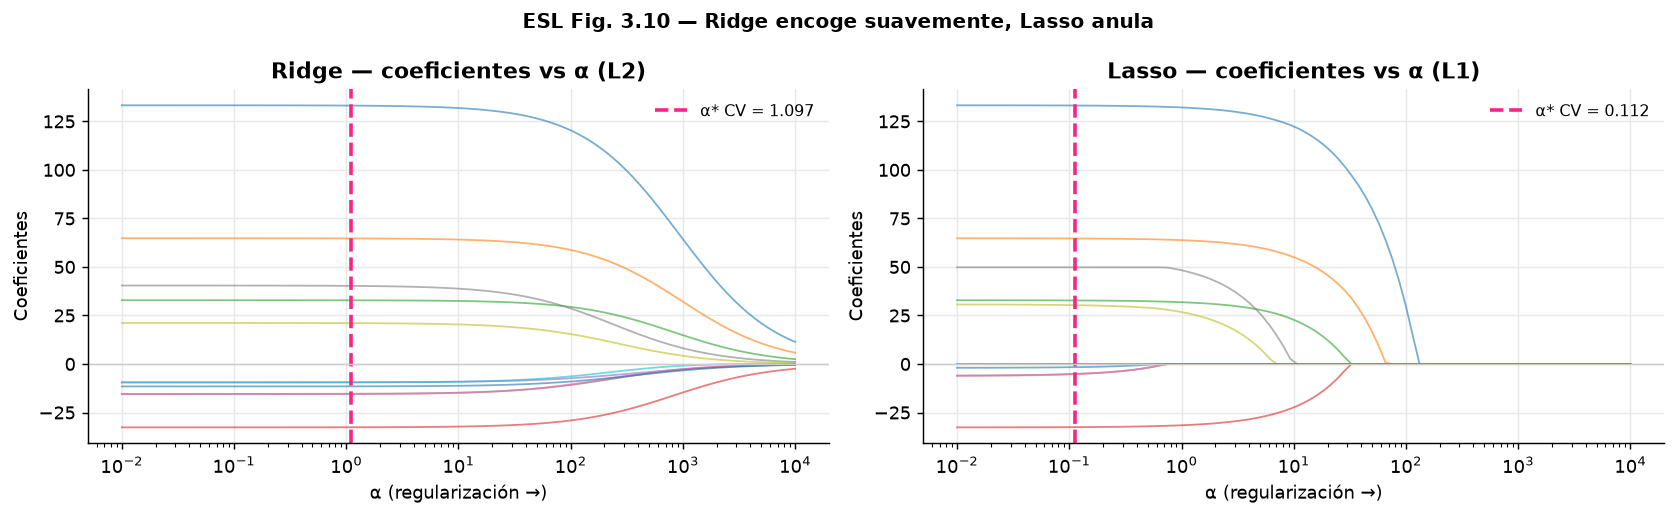

Con α_max: Lasso anuló 11/11 coeficientes


In [4]:
alphas_plot = np.logspace(-2, 4, 100)
ridge_coefs = []
lasso_coefs = []

for a in alphas_plot:
    ridge_coefs.append(Ridge(alpha=a).fit(X_prep, y_train).coef_)
    lasso_coefs.append(Lasso(alpha=a, max_iter=10000).fit(X_prep, y_train).coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for coefs, ax, title, alpha_opt in [
    (ridge_coefs, axes[0], 'Ridge — coeficientes vs α (L2)', ridge_cv.alpha_),
    (lasso_coefs, axes[1], 'Lasso — coeficientes vs α (L1)', lasso_cv.alpha_),
]:
    for j in range(coefs.shape[1]):
        ax.plot(alphas_plot, coefs[:, j], alpha=0.6, linewidth=1)
    ax.axvline(alpha_opt, color='#f72585', linewidth=2, linestyle='--', label=f'α* CV = {alpha_opt:.3f}')
    ax.set_xscale('log')
    ax.set_xlabel('α (regularización →)')
    ax.set_ylabel('Coeficientes')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.axhline(0, color='#ccc', linewidth=0.8)

plt.suptitle('ESL Fig. 3.10 — Ridge encoge suavemente, Lasso anula', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Cuántos coeficientes anuló Lasso?
n_zero = (np.abs(lasso_coefs[-1]) < 1e-6).sum()
print(f'Con α_max: Lasso anuló {n_zero}/{lasso_coefs.shape[1]} coeficientes')

## 4 — Polynomial Features + Ridge (Géron Cap. 4)

/Volumes/SSD_Gabo/proyectos/growth-analytics/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.293241826535659e-24.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


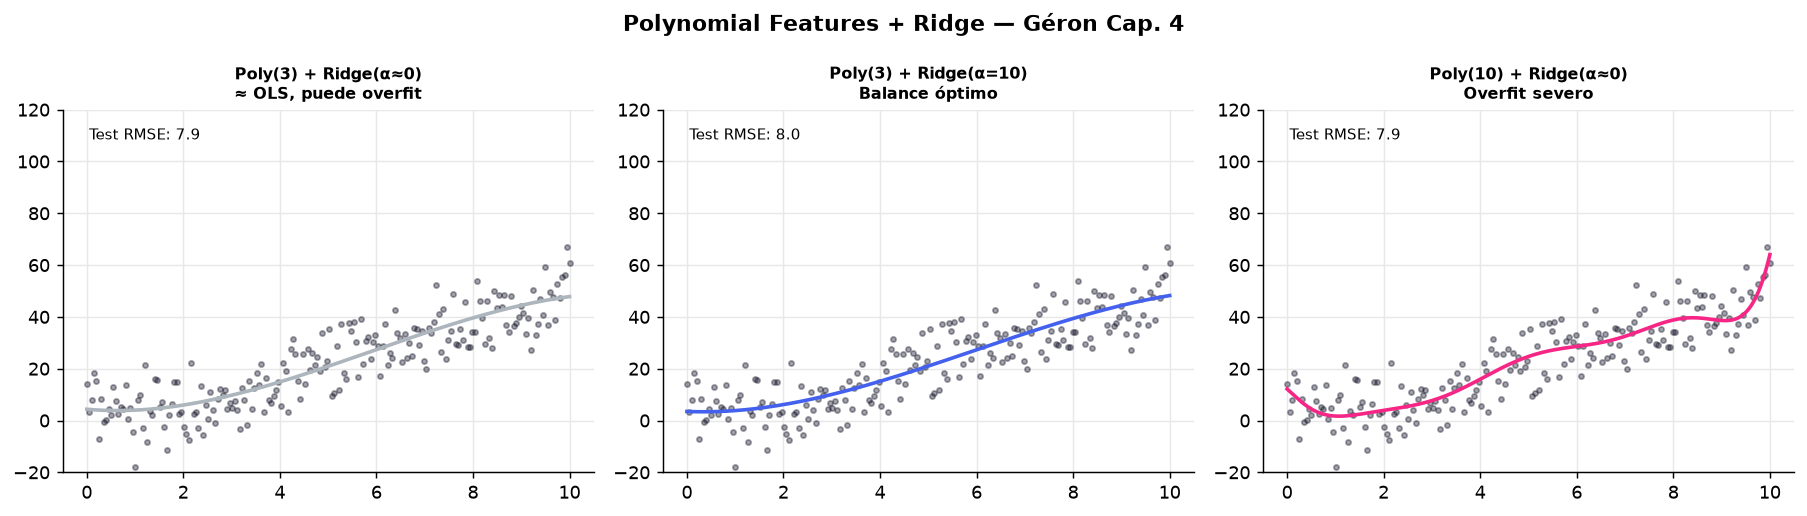

In [5]:
# Con datos numéricos simples para visualizar
np.random.seed(0)
x = np.linspace(0, 10, 200)
y_poly = 2*x + 0.5*x**2 - 0.02*x**3 + np.random.normal(0, 8, 200)

X_poly = x.reshape(-1,1)
X_poly_tr, X_poly_te, y_poly_tr, y_poly_te = train_test_split(X_poly, y_poly, test_size=0.3, random_state=0)

x_line = np.linspace(0, 10, 300).reshape(-1,1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
configs = [
    (3,  1e-3,  '#adb5bd', 'Poly(3) + Ridge(α≈0)\n≈ OLS, puede overfit'),
    (3,  10,    '#4361ee', 'Poly(3) + Ridge(α=10)\nBalance óptimo'),
    (10, 1e-3,  '#f72585', 'Poly(10) + Ridge(α≈0)\nOverfit severo'),
]
for ax, (deg, alpha, color, title) in zip(axes, configs):
    pipe = Pipeline([('poly', PolynomialFeatures(deg)), ('model', Ridge(alpha=alpha))])
    pipe.fit(X_poly_tr, y_poly_tr)
    te_rmse = (mean_squared_error(y_poly_te, pipe.predict(X_poly_te)) ** 0.5)
    ax.scatter(x, y_poly, color='#1a1a2e', s=8, alpha=0.4)
    ax.plot(x_line, pipe.predict(x_line), color=color, linewidth=2)
    ax.set_title(title, fontsize=9)
    ax.set_ylim(-20, 120)
    ax.text(0.05, 0.95, f'Test RMSE: {te_rmse:.1f}', transform=ax.transAxes, fontsize=8.5, va='top')

plt.suptitle('Polynomial Features + Ridge — Géron Cap. 4', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5 — Interpretación estadística de coeficientes (ESL 3.2)

In [6]:
from scipy import stats

# OLS manual para obtener p-values e intervalos de confianza
X_prep_full = preprocessor.fit_transform(X_train)
n_tr, p = X_prep_full.shape

lr = LinearRegression().fit(X_prep_full, y_train)
y_hat   = lr.predict(X_prep_full)
resid   = y_train.values - y_hat
sigma2  = np.sum(resid**2) / (n_tr - p - 1)      # estimador insesgado de σ²

# Varianza de coeficientes: Var(β̂) = σ² (XᵀX)⁻¹  (ESL 3.10)
XtX_inv  = np.linalg.pinv(X_prep_full.T @ X_prep_full)
var_beta = sigma2 * np.diag(XtX_inv)
se_beta  = np.sqrt(var_beta)
t_stats  = lr.coef_ / se_beta
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n_tr - p - 1))

cat_names_inf = list(preprocessor.named_transformers_['cat'].get_feature_names_out())
feat_names_inf = num_features + cat_names_inf

coef_table = pd.DataFrame({
    'feature':   feat_names_inf,
    'coef':      lr.coef_.round(3),
    'std_error': se_beta.round(3),
    't_stat':    t_stats.round(3),
    'p_value':   p_values.round(4),
    'signif':    ['***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else '' for p in p_values],
}).sort_values('p_value')

print('Inferencia estadística sobre coeficientes (ESL 3.2):')
print(coef_table.to_string(index=False))
print('\n*** p<0.001  ** p<0.01  * p<0.05')

Inferencia estadística sobre coeficientes (ESL 3.2):
        feature    coef  std_error  t_stat  p_value signif
       sessions 133.284      1.929  69.097   0.0000    ***
   time_on_site  64.764      1.923  33.679   0.0000    ***
          pages  32.857      1.923  17.087   0.0000    ***
 days_since_reg -32.655      1.927 -16.946   0.0000    ***
  channel_email -15.430      3.344  -4.614   0.0000    ***
channel_organic -15.601      3.557  -4.386   0.0000    ***
   channel_paid  40.427      3.441  11.748   0.0000    ***
 device_desktop  21.129      2.877   7.344   0.0000    ***
  device_tablet -11.555      2.979  -3.879   0.0001    ***
  device_mobile  -9.574      2.949  -3.247   0.0012     **
 channel_direct  -9.396      3.384  -2.777   0.0056     **

*** p<0.001  ** p<0.01  * p<0.05


## Resumen — ¿Cuándo usar cada modelo?

| Modelo | Solución | Cuándo | Referencia |
|---|---|---|---|
| `LinearRegression` | $(X^TX)^{-1}X^Ty$ | Baseline, features independientes | ESL 3.1 |
| `Ridge` | $(X^TX+\lambda I)^{-1}X^Ty$ | Multicolinealidad, nunca anula | ESL 3.4.1 |
| `Lasso` | LARS/CD | Selección de features automática | ESL 3.4.2 |
| `ElasticNet` | Combinación L1+L2 | Muchas features correlacionadas | ESL 3.4.3 |
| `RidgeCV`/`LassoCV` | CV interna | Ahorra un GridSearchCV | Géron Cap. 4 |

**Siguiente:** `04_classification.ipynb`